In [1]:
import numpy as np
import pandas as pd
import torch
import unittest
import os
import sys
import pathlib
import urllib
import shutil
import re

import numpy as np
import torch
import matplotlib.pyplot as plt

import pickle


%load_ext autoreload
%autoreload 2

In [2]:
from torch.utils.data import DataLoader, Dataset

import numpy as np
from datasets import DatasetDict
from datasets import load_dataset, load_metric, concatenate_datasets

from hw3 import training


from cs236781.plot import plot_fit
from cs236781.train_results import FitResult

$$
\newcommand{\mat}[1]{\boldsymbol {#1}}
\newcommand{\mattr}[1]{\boldsymbol {#1}^\top}
\newcommand{\matinv}[1]{\boldsymbol {#1}^{-1}}
\newcommand{\vec}[1]{\boldsymbol {#1}}
\newcommand{\vectr}[1]{\boldsymbol {#1}^\top}
\newcommand{\rvar}[1]{\mathrm {#1}}
\newcommand{\rvec}[1]{\boldsymbol{\mathrm{#1}}}
\newcommand{\diag}{\mathop{\mathrm {diag}}}
\newcommand{\set}[1]{\mathbb {#1}}
\newcommand{\norm}[1]{\left\lVert#1\right\rVert}
\newcommand{\pderiv}[2]{\frac{\partial #1}{\partial #2}}
\newcommand{\bb}[1]{\boldsymbol{#1}}
$$
# Part 4: Fine-Tuning a pretrained language model
<a id=part3></a>

In this part , we will deal with the fine-tuning of BERT for sentiment analysis on the IMDB movie reivews dataset from the previous section.   
BERT is a large language model developed by Google researchers in 2019 that offers a good balance between popularity and model size, which can be fine-tuned using a simple GPU.  

If you aren't yet familiar, you can check it out here:  
https://arxiv.org/pdf/1810.04805.pdf.
(Read Section 3 for details on the model architecture and fine-tuning on downstream tasks).

In particular, we will use the distilled (smaller) version of BERT, called Distil-BERT.
Distil-BERT is widely used in production since it has 40% fewer parameters than BERT, while running 60% faster and retaining 95% of the performance in many benchmarks.
It is recommended to glance through the Distil-BERT paper to get a feel for the model architecture and how it differs from BERT: 
https://arxiv.org/pdf/1910.01108.pdf

We will download a pre-trained `Distil-BERT` from `Hugging Face`, so there is no need to train it from scratch. 

One of the key strengths of Hugging Face is its extensive collection of pre-trained models. These models are trained on large-scale datasets and exhibit impressive performance on various NLP tasks, such as text classification, named entity recognition, sentiment analysis, machine translation, and question answering, among others. The pre-trained models provided by Hugging Face can be easily fine-tuned for specific downstream tasks, saving significant time and computational resources.  


## Loading the Dataset

We will now load and prepare the IMDB dataset as we did in the previous part.  
Here we will load the full training and test set.


In [3]:
dataset = load_dataset('imdb', split=['train', 'test[12260:12740]'])

Reusing dataset imdb (C:\Users\TA\.cache\huggingface\datasets\imdb\plain_text\1.0.0\e3c66f1788a67a89c7058d97ff62b6c30531e05b549de56d3ab91891f0561f9a)


In [4]:
print(dataset)

[Dataset({
    features: ['text', 'label'],
    num_rows: 25000
}), Dataset({
    features: ['text', 'label'],
    num_rows: 480
})]


In [5]:
#wrap it in a DatasetDict to enable methods such as map and format
dataset = DatasetDict({'train': dataset[0], 'test': dataset[1]})

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 480
    })
})

We can now access the datasets in the Dict as we would a dictionary.
Let's print a few training samples

In [7]:
for i in range(4):
    print(f'TRAINING SAMPLE {i}:') 
    print(dataset['train'][i]['text'])
    label = dataset['train'][i]['label']
    print(f'Label {i}: {label}')
    print('\n')

TRAINING SAMPLE 0:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!
Label 0: 1


TRAINING SAMPLE 1:
Homelessness (or Houselessness as George Carlin stated) has been an issue for years but never a plan to help those on the street that were onc

We should also check the label distribution:

In [8]:
def label_cnt(type):
    ds = dataset[type]
    size = len(ds)
    cnt= 0 
    for smp in ds:
        cnt += smp['label']
    print(f'negative samples in {type} dataset: {size - cnt}')
    print(f'positive samples in {type} dataset: {cnt}')
    
label_cnt('train')
label_cnt('test')

negative samples in train dataset: 12500
positive samples in train dataset: 12500
negative samples in test dataset: 240
positive samples in test dataset: 240


### __Import the tokenizer for the dataset__


We will now tokenize the text the same way we did in the previous part.



In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
print("Tokenizer input max length:", tokenizer.model_max_length)
print("Tokenizer vocabulary size:", tokenizer.vocab_size)

Tokenizer input max length: 512
Tokenizer vocabulary size: 30522


In [10]:
def tokenize_text(batch):
    return tokenizer(batch["text"], truncation=True, padding=True)

def tokenize_dataset(dataset):
    dataset_tokenized = dataset.map(tokenize_text, batched=True, batch_size =None)
    return dataset_tokenized

dataset_tokenized = tokenize_dataset(dataset)
# we would like to work with pytorch so we can manually fine-tune
dataset_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "label"])
# no need to parrarelize in this assignment
os.environ["TOKENIZERS_PARALLELISM"] = "false"

Parameter 'function'=<function tokenize_text at 0x000002967D8BA940> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


  0%|          | 0/1 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

### Setting up the dataloaders and dataset

We will now set up the dataloaders for efficient batching and loading of the data.  
By now, you are familiar with the Class methods that are needed to create a working Dataloader.


In [11]:
class IMDBDataset(Dataset):
    def __init__(self, dataset):
        self.ds = dataset

    def __getitem__(self, index):
        return self.ds[index]

    def __len__(self):
        return self.ds.num_rows

In [12]:
train_dataset = IMDBDataset(dataset_tokenized['train'])
test_dataset = IMDBDataset(dataset_tokenized['test'])

In [13]:

n_workers= 0

dl_train,dl_test = [ 
    DataLoader(
    dataset=train_dataset,
    batch_size=12,
    shuffle=True, 
    num_workers=n_workers
),
DataLoader(
    dataset=test_dataset,
    batch_size=12,
    shuffle=False,
    num_workers=n_workers
)]

In [14]:
dl_train

## Importing the model from Hugging Face
We will now  delve into the process of loading the DistilBERT model from `Hugging Face`. DistilBERT is a distilled version of the BERT model, offering a lighter and faster alternative while retaining considerable performance on various NLP tasks.  
Please refer to the introduction to check out the relevant papers.  
For more info on how to use this model, feel free to check it out on the site:  
https://huggingface.co/distilbert-base-uncased 



To begin, we will import the necessary library required for our implementation.
It is fine if you receive a warning from `Hugging Face` to train the model on a downstream task, which is exactly what we will do on our IMDB dataset. 

In [15]:
from transformers import AutoModelForSequenceClassification


In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


__Let's print the model architecture to see what we are dealing with:__

In [17]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Fine Tuning
We will now move on to the process of fine-tuning the model that we previously loaded from `Hugging Face`. Fine-tuning allows us to adapt the pre-trained model to our specific NLP task by further training it on task-specific data. This process enhances the model's performance and enables it to make more accurate predictions on our target task.  

There are generally two approaches to fine-tuning the loaded model, each with its own advantages and considerations:  

1) __Freeze all the weights besides the last two linear layers and train only those layers__:  
This approach is commonly referred to as "transfer learning" or "feature extraction." By freezing the weights of the majority of the model's layers, we retain the pre-trained knowledge captured by the model, allowing it to extract useful features from our data. We then replace and train the final few layers, typically linear layers, to adapt the model to our specific task. This method is beneficial when we have limited labeled data or when the pre-trained model has been trained on a similar domain.

2) __Retrain all the parameters in the model__:  
This approach involves unfreezing and training all the parameters of the loaded model, including the pre-trained layers. By retraining all the parameters, we allow the model to adjust its representations and update its knowledge based on our specific task and data. This method is often preferred when we have sufficient labeled data available and want the model to learn task-specific features from scratch or when the pre-trained model's knowledge may not be directly applicable to our domain.

### Fine-tuning method 1 
__Freeze all the weights besides the last two linear layers and train only those layers__



In [18]:
# TODO:
# Freeze all parameters except for the last 2 linear layers
# ====== YOUR CODE: ======
_ = [param.requires_grad_(False) for name, param in model.named_parameters() if "classifier" not in name]
# ========================

# HINT: use the printed model architecture to get the layer names




### Training 
We can use our abstract __Trainer__ class to fine-tune the model:
We will not play around with hyperparameters in this section, as the point is to learn to fine-tune a model.   
In addition, we do not need to send our own loss function for this loaded model (try to understand why).   

__TODO__: Implement the `FineTuningTrainer` in `hw3/training.py`

We will train the model for 2 epochs of 40 batches.  
You can run this either locally or on the course servers, whichever is most comfortable for you.

In [20]:
from hw3 import training

optimizer = torch.optim.Adam(model.parameters(), lr = 5e-5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# fit your model
if not os.path.exists('finetuned_last_2.pt'):
    trainer = training.FineTuningTrainer(model, loss_fn = None, optimizer = optimizer,device = device)
    fit_result = trainer.fit(dl_train,dl_test, checkpoints='finetuned_last_2', num_epochs=2, max_batches= 40)
    with open('fit_result_finetune_2.pkl', 'wb') as f:
        pickle.dump(fit_result, f)
    

saved_state = torch.load('finetuned_last_2.pt',map_location = device)
model.load_state_dict(saved_state['model_state']) 
best_acc = saved_state['best_acc']
print('best acc:', best_acc)

with open('fit_result_finetune_2.pkl', 'rb') as f:
    fit_result = pickle.load(f) 



--- EPOCH 1/2 ---
train_batch (Avg. Loss 0.692, Accuracy 54.0): 100%
test_batch (Avg. Loss 0.666, Accuracy 77.1): 100%|
*** Saved checkpoint finetuned_last_2.pt at epoch 1
--- EPOCH 2/2 ---
train_batch (Avg. Loss 0.660, Accuracy 67.7): 100%
test_batch (Avg. Loss 0.641, Accuracy 76.9): 100%|


C:\Users\TA\AppData\Local\Temp\ipykernel_111128\279017373.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_state = torch.load('finetuned_last_2.pt',map_location = 

best acc: 77.08333333333333


(<Figure size 1600x1000 with 4 Axes>,
 array([<Axes: title={'center': 'train_loss'}, xlabel='Iteration #', ylabel='Loss'>,
        <Axes: title={'center': 'train_acc'}, xlabel='Epoch #', ylabel='Accuracy (%)'>,
        <Axes: title={'center': 'test_loss'}, xlabel='Iteration #', ylabel='Loss'>,
        <Axes: title={'center': 'test_acc'}, xlabel='Epoch #', ylabel='Accuracy (%)'>],
       dtype=object))

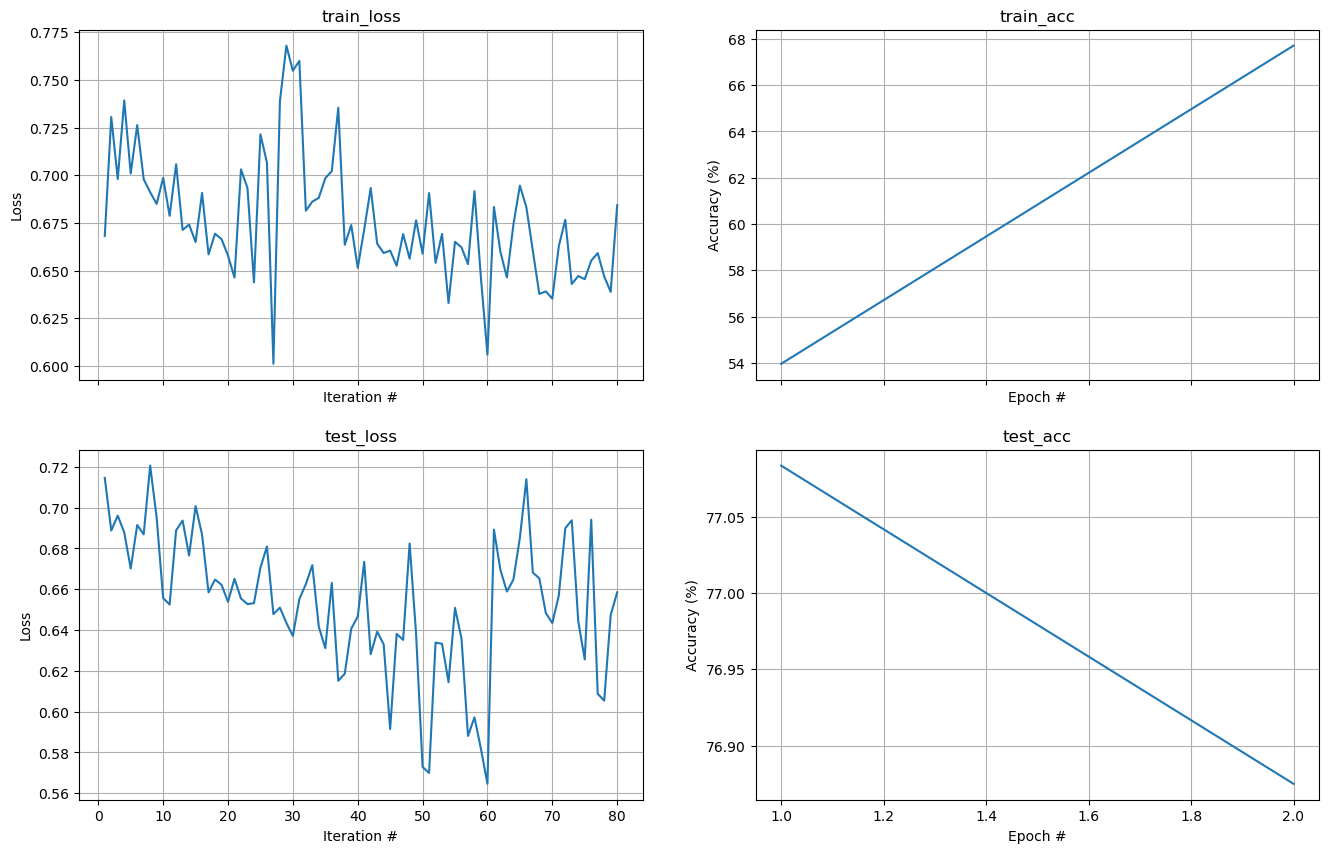

In [21]:
plot_fit(fit_result)

### Fine-tuning method 2 
__Retraining all the parameters in the model__

We will reload the model to ensure that the parameters are untouched and we are starting from scratch

In [22]:
from transformers import AutoModelForSequenceClassification


In [23]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [25]:
# TODO: Make sure all the model parameters are unfrozen
# ====== YOUR CODE: ======
_ = [param.requires_grad_(True) for param in model.parameters()]

# ========================

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr = 5e-5)

# fit your model
if not os.path.exists('finetuned_all.pt'):
    trainer = training.FineTuningTrainer(model, loss_fn = None, optimizer = optimizer, device = device)
    fit_result = trainer.fit(dl_train,dl_test, checkpoints='finetuned_all', num_epochs=2, max_batches= 40)
    with open('finetuned_all.pkl', 'wb') as f:
        pickle.dump(fit_result, f)
    

saved_state = torch.load('finetuned_all.pt',map_location = device)
model.load_state_dict(saved_state['model_state']) 

with open('finetuned_all.pkl', 'rb') as f:
    fit_result = pickle.load(f)  


--- EPOCH 1/2 ---
train_batch (Avg. Loss 0.543, Accuracy 71.9): 100%
test_batch (Avg. Loss 0.358, Accuracy 86.0): 100%|
*** Saved checkpoint finetuned_all.pt at epoch 1
--- EPOCH 2/2 ---
train_batch (Avg. Loss 0.293, Accuracy 88.8): 100%
test_batch (Avg. Loss 0.412, Accuracy 83.8): 100%|


C:\Users\TA\AppData\Local\Temp\ipykernel_111128\3245219772.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_state = torch.load('finetuned_all.pt',map_location = de

(<Figure size 1600x1000 with 4 Axes>,
 array([<Axes: title={'center': 'train_loss'}, xlabel='Iteration #', ylabel='Loss'>,
        <Axes: title={'center': 'train_acc'}, xlabel='Epoch #', ylabel='Accuracy (%)'>,
        <Axes: title={'center': 'test_loss'}, xlabel='Iteration #', ylabel='Loss'>,
        <Axes: title={'center': 'test_acc'}, xlabel='Epoch #', ylabel='Accuracy (%)'>],
       dtype=object))

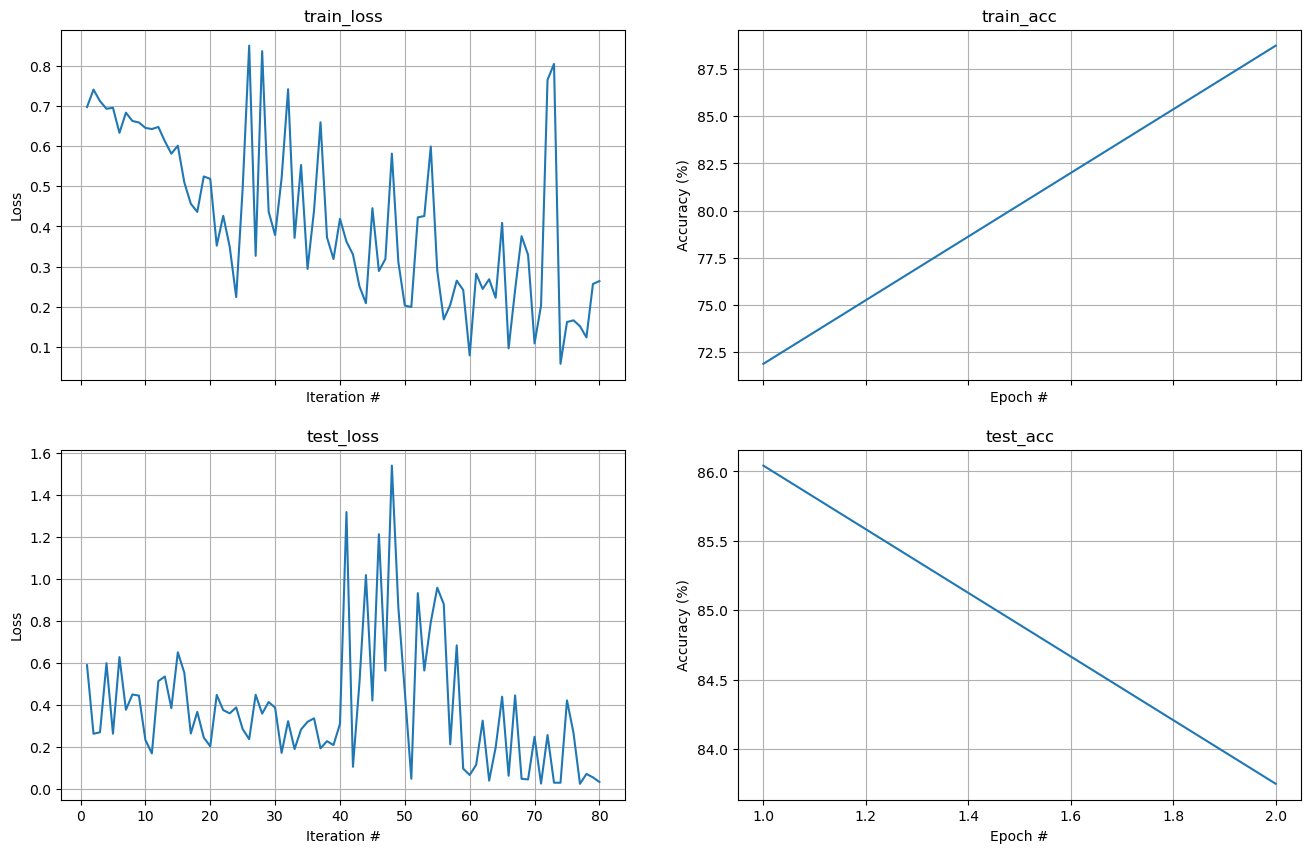

In [27]:
plot_fit(fit_result)

## Questions

Fill out your answers in `hw3.answers.part4_q1` and `hw3.answers.part4_q2`

In [1]:
from cs236781.answers import display_answer
import hw3.answers

### Question 1

Explain the results that you got here in comparison to the results achieved in the *trained from scratch* encoder from the preivous part.  
If one of the models performed better, why was this so?   
Will this always be the case on any downstream task, or was this phenomenom specific to this task?


In [2]:
display_answer(hw3.answers.part5_q1)


**Your answer:**

The fine-tuned encoder performed better than the encoder trained from scratch, showing faster convergence and higher accuracy. This is because the fine-tuned model benefits from pre-trained knowledge, which captures general language patterns and representations. This prior knowledge allows the model to adapt quickly to similar tasks with minimal training effort. However, this phenomenon depends on the task. Fine-tuning is most effective when the downstream task aligns with the pre-training data. For highly domain-specific tasks, training from scratch may sometimes yield better results if pre-trained knowledge is less relevant or even detrimental.



### Question 2

Assume that when fine-tuning, instead of freezing the internal model layers and leaving the last 2 layers unfrozen, we instead froze the last layers and fine-tuned internal layers such as the multi-headed attention block .
Would the model still be able to succesfully fine-tune to this task?   
Or would the results be worse?  
Explain  

In [3]:
display_answer(hw3.answers.part5_q2)


**Your answer:**

Assuming the model fine-tunes successfully, freezing the final layers and fine-tuning internal layers like the multi-headed attention block might limit task-specific adaptation. Since the final layers capture high-level features relevant to the task, preventing their adjustment could reduce the model's ability to fully adapt. Additionally, modifying deeper internal layers increases the risk of overfitting to non-relevant patterns, especially with limited task-specific data, making this approach potentially less optimal.



### Question 3

If you want to conduct a machine translation task, as seen in the tutorials, can you use BERT?

Describe the modulation you need to do, i.e. if the source tokens are $x_t$ and the target are $y_t$, how would the model work to produce the translation?

If the model can't handle this task, describe the architecture changes and why you need them. If a change in the pre-training is required, describe it as well.

In [4]:
display_answer(hw3.answers.part5_q3)


**Your answer:**

No, BERT alone cannot handle machine translation because it is not designed for autoregressive generation. It predicts masked tokens within a sequence but cannot generate target sequences step by step. In my opinion, a possible solution would be to modify BERT into an encoder-decoder structure by adding a decoder block for sequential prediction. Additionally, pre-training should include sequence-to-sequence tasks to improve generation performance.



### Question 4

We saw in the course two types on sequntial modeling: RNN and Transformers.

What could be the main reason to choose RNN over a Transformer? Note that both can be light weight or heavy in computation.

In [5]:
display_answer(hw3.answers.part5_q4)


**Your answer:**

A main reason to choose RNN over a Transformer is its inherent ability to model continuous and time-dependent data, such as real-time signal processing or continuous speech generation, where sequential order is crucial. RNNs maintain a persistent internal state, which allows them to naturally handle temporal patterns without relying on position encoding.



### Question 5

We have learned that BERT uses "Next Sentence Prediction" (NSP) as part of the pre-training tasks.

Describe what it is (where is the prediction accure, what is the loss).

Do you think this is a crucial part of pre-training? try to analize why you gave the answer, i.e. what essensity it gives to the model, or why it's implicitly don't contibute much. 


In [6]:
display_answer(hw3.answers.part5_q5)


**Your answer:**

**Next Sentence Prediction (NSP)** is a pre-training task in BERT where the model predicts whether a sentence \(B\) logically follows sentence \(A\). It’s framed as a binary classification problem with *IsNext* or *NotNext* labels, using **binary cross-entropy loss** for optimization.

**Is it crucial?**  
In my opinion, it depends on the task. NSP is valuable for tasks requiring sentence-level understanding, such as **question answering**. However, for token-level tasks like **named entity recognition**, NSP contributes less since relationships between sentences are less critical.

